##### sequence - To automatically handle the state update for sequences such as by adding new messages to the chat.

In [1]:
from typing import Annotated, TypedDict, Sequence

from dotenv import load_dotenv

from langchain_core.messages import (
    BaseMessage,
    SystemMessage,
    HumanMessage,
    AIMessage,
)
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

load_dotenv()

True

In [2]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [3]:
@tool
def add_numbers(a: int, b: int) -> int:
    """Return the sum of two integers."""
    return a + b


@tool
def subtract_numbers(a: int, b: int) -> int:
    """Return the difference of two integers."""
    return a - b

In [4]:
tools = [add_numbers, subtract_numbers]

model = ChatGoogleGenerativeAI(
    # model="gemini-2.5-flash-lite",
    model="gemini-2.5-flash",
    temperature=1.0,
).bind_tools(tools)


In [5]:
def llm_node(state: AgentState) -> AgentState:
    """
    Reasoning node.
    Invokes the LLM using the current conversation state.
    """
    response = model.invoke(state["messages"])
    return {"messages": [response]}


def should_continue(state: AgentState) -> str:
    """
    Control logic for the ReAct loop.

    If the last AI message contains tool calls → execute tools.
    Otherwise → finish.
    """
    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tools"

    return END

In [6]:
def build_agent():
    """
    Build and compile the LangGraph agent.
    """
    graph = StateGraph(AgentState)

    # Nodes
    graph.add_node("llm", llm_node)
    graph.add_node("tools", ToolNode(tools))

    # Edges
    graph.add_edge(START, "llm")
    graph.add_conditional_edges(
        "llm",
        should_continue,
        {
            "tools": "tools",
            END: END,
        },
    )
    graph.add_edge("tools", "llm")

    return graph.compile()

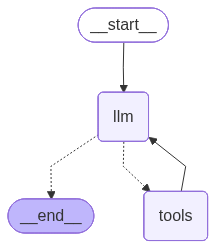

In [7]:
app = build_agent()
app

In [23]:
def print_stream(stream):
    """
    Safe, provider-agnostic streaming printer.
    """
    for update in stream:
        for node_name, data in update.items():
            print(f"\n🔹 Node: {node_name}")
            for msg in data.get("messages", []):
                if isinstance(msg, AIMessage):
                    print(f"🤖 AI: {msg.content_blocks}")
                elif isinstance(msg, HumanMessage):
                    print(f"👤 Human: {msg.content}")
                elif isinstance(msg, SystemMessage):
                    print(f"⚙️ System: {msg.content}")
                else:
                    print(f"📨 Message: {msg}")

In [24]:
inputs = {"messages":
              [
                SystemMessage(content="You are a helpful assistant."),
                HumanMessage(content="What is 5 plus 7, and 15 minus 14?")
              ]
          }

In [25]:
print_stream(app.stream(inputs, stream_mode="updates"))


🔹 Node: llm
🤖 AI: [{'type': 'tool_call', 'id': 'ab25179a-9789-46c3-97c2-06017946e8a6', 'name': 'add_numbers', 'args': {'b': 7, 'a': 5}}]

🔹 Node: tools
📨 Message: content='12' name='add_numbers' id='e3460acc-83ae-41ec-a9fa-c362522e33f7' tool_call_id='ab25179a-9789-46c3-97c2-06017946e8a6'

🔹 Node: llm
🤖 AI: [{'type': 'tool_call', 'id': '92bb90b4-7652-4b15-b8f3-50fd5036cc53', 'name': 'subtract_numbers', 'args': {'a': 15, 'b': 14}}]

🔹 Node: tools
📨 Message: content='1' name='subtract_numbers' id='3e6e0d6c-4861-404a-a148-a89ae6ab3764' tool_call_id='92bb90b4-7652-4b15-b8f3-50fd5036cc53'

🔹 Node: llm
🤖 AI: [{'type': 'text', 'text': '5 plus 7 is 12, and 15 minus 14 is 1.'}]
